# EDA와 데이터 시각화

**데이터 셋**: 남극 펭귄 데이터셋 (penguins.csv)

**학습 목표**
- groupby 와 상관관계로 변수 간 관계를 수치로 파악할 수 있다.
- 범주형과 수치형 데이터를 서로 변환할 수 있다. (qcut, label encoding 등)
- 데이터 유형에 맞는 시각화 방법을 선택할 수 있다.
- 두 변수 이상의 관계를 다양한 그래프로 표현할 수 있다.

## 0. 환경 설정

**한글 폰트 설정**: Colab의 matplotlib은 기본적으로 한글이 깨집니다.
`koreanize-matplotlib` 패키지를 한 번만 설치하면 모든 그래프에서 한글이 정상으로 표시합니다.
**데이터**: `penguins.csv'를 Colab파일 패널에 드래그&드롭해서 업로드해두세요.

In [9]:
# 한글 폰트 설치 및 적용 (한 번만 실행)
try:
  import koreanize_matplotlib
except:
  !pip install koreanize-matplotlib -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 19.9 MB/s eta 0:00:00


In [10]:
import koreanize_matplotlib
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
df = pd.read_csv('penguins.csv')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [11]:
# 결측치 / 중복값 처리를 한 번에 적용
num_cols = ['bill_length_mm', 'bill_depth_mm','flipper_length_mm', 'body_mass_g']
for col in num_cols:
  df[col] = df[col].fillna(df[col].median()) # 수치형 누락값을 중앙값으로 대체
df['sex'] = df['sex'].fillna(df['sex'].mode()[1]) # 범주형 누락값 최빈값 대체
df = df.drop_duplicates().reset_index(drop=True) # 중복값 제거 후 다시 인덱스
print(f"데이터 크기: {df.shape}\n 결측치: {df.isnull().sum().sum()}개")
df.head()

데이터 크기: (344, 8)
 결측치: 0개


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,44.5,17.3,197.0,4050.0,male,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


# Part A. EDA - 수치로 데이터 탐색하기

## 1. 컬럼별 특징 확인

### 1-1. 데이터 유형 분류

분석을 시작하기 전, 각 컬럼이 **수치형인지, 범주형인지** 분류합니다. 사용할 수 있는 통계와 시각화 방법이 달라지기 때문입니다.

| 유형 | 예시 | 가능한 분석 |
|---|---|---|
| 수치형 (연속) | 부리 길이, 체중 | 평균, 분산, 히스토그램 |
| 범주형 (명목) | 종, 섬, 성별 | 빈도, 막대그래프 |

In [12]:
# 컬럼별 데이터 타입을 확인하세요.
df.____

AttributeError: 'DataFrame' object has no attribute '____'

In [ ]:
# 수치형 컬럼만 선별 (select_dtypes 사용)
num_df = df.select_dtypes(include='number') #exclude='object')
print(f"수치형 컬럼 개수: {len(num_df.columns)}\n 수치형 컬럼: {num_df.columns.tolist()}")
# 범주형 컬럼만 선별 (select_dtypes 사용)
cat_df = df.select_dtypes(exclude='number') #include='object')
print(f"범주형 컬럼 개수: {len(cat_df.columns)}\n 범주형 컬럼: {cat_df.columns.tolist()}")
num_df.head()
#

### 1-2. 수치형 컬럼 요약 통계

In [ ]:
# 수치형 컬럼들의 기술 통계량을 한 번에 출력하세요.
df[num_cols].____________()

In [ ]:
# body_mass_g의 평균과 중앙값의 차이를 출력하세요.
mean_val = df['body_mass_g'].mean()
median_val = df['body_mass_g'].median()
print(f"평균과 중앙값의 차이: {mean_val - median:.1f}")

### 1-3. 범주형 컬럼 요약 통계

In [ ]:
# species 컬럼의 값별 빈도를 출력하세요.
df['species']._________()

In [ ]:
# island, sex 각각의 빈도를 한 번씩 출력하세요.
for col in ['island', 'sex']:
  print(f"----{col}----")
  print(df[col].________())
  print()

**[실습 1-1]** 어느 종(species)이 가장 많은가? 어느 섬(island)에 가장 많은 펭귄이 사는가?

## 2. Groupby - 그룹별 집계

`groupby`는 **범주별로 데이터를 묶어 통계를 계산**하는 핵심 도구입니다.

"A 그룹과 B 그룹의 평균이 다른가?" 라는 질문에 수치로 답합니다.

``` python
df.groupby('컬럼')['집계대상'].집계함수()            # 단일 키
df.groupby(['키 1', '키 2'])['대상'].집계()          # 복수 키
df.groupby('키').agg({'A': 'mean', 'B':'sum'})  # 컬럼별로 다른 함수
```


In [ ]:
# species 별 평균 body_mass_g을 구하세요.
df.________('species').________[:,'body_mass_g'].________()

In [ ]:
# species 별 평균 body_mass_g의 mean, median, std를 한번에 구하세요.(agg 사용)
df.________('species')._____[:,'body_mass_g'].____['mean', 'median', 'std']

In [ ]:
# species + sex 두 키로 그룹화해서 평균 body_mass_g을 보세요.
df.groupby(['species', 'sex'])['body_mass_g'].____()

In [ ]:
# 위 결과를 표 형태(피벗)로 보고 싶으면 맨 뒤에 unstack()을 붙입니다.
df.groupby(['species', 'sex'])['body_mass_g'].____().______()

In [ ]:
# 한 번에 여러 컬럼에 다른 집계 함수를 적용 (딕셔너리로)
df.groupby('species').agg( {  'body_mass_g': 'mean',
                            'flipper_length_mm':'max',
                            'bill_length_mm': ['min', 'max']  } )
#

**[실습 2-1]** 섬(island)별로 펭귄 수와 평균 부리 길이(bill_length_mm)를 한 번에 출력하세요.

In [ ]:
# 여기에 작성하세요. (힌트: agg에 'count'와 'mean'을 함께 사용)

## 3. 컬럼 간 상관관계

### 3-1. 수치형 vs 수치형: 상관계수

두 수치형 변수가 함께 변하는 정도를 -1 ~ 1로 표현합니다.

| 절대값 | 해석 |
|---|---|
| 0.7 ~ 1.0 | 강한 상관관계 |
| 0.5 ~ 0.7 | 중간 상관관계 |
| 0.3 ~ 0.5 | 약한 상관관계 |
| 0.0 ~ 0.3 | 상관관계가 거의 없음 |

**주의**: 상관관계는 인과관계가 아닙니다.

In [ ]:
# 수치형 컬럼들 간의 상관계수 행렬을 구하세요.
df[num_cols].____()

In [ ]:
# bill_length_mm과 body_mass_g 두 컬럼만의 상관계수
df[['bill_length_mm', 'body_mass_g']].____().iloc[_______, ________]

### 3-2. 범주형 vs 범주형: 교차표

두 범주형 변수의 조합별 빈도(또는 비율)를 표로 만듭니다.

In [14]:
import pandas as pd
df = pd.read_csv('penguins.csv')
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])
df = df.drop_duplicates().reset_index(drop=True)
print(f"데이터 크기: {df.shape}, 결측치: {df.isnull().sum().sum()}개")
# species와 island의 교차표
pd._______(df['species'], df['island'])

데이터 크기: (344, 8), 결측치: 0개


island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


In [ ]:
# 비율로 보고 싶다면 normalize 옵션 ('index'는 행 기준)
pd._______(df['species'], df['island'], normalize=____)

### 3-3. 범주형 vs 수치형: 그룹별 비교

In [ ]:
# sex 기준으로 body_mass_g의 평균을 보는 코드를 작성하세요.
df.groupby(_____)['body_mass_g'].____()

**[실습3-1]** body_mass_g과 가장 강한 상관관계(절대값 기준)를 보이는 컬럼을 찾으세요.

In [ ]:
# 여기에 작성하세요.
num_cols = df.select_dtypes(include='number').columns.tolist()
corr = df[num_cols].corr()['body_mass_g'].drop('body_mass_g')
corr = corr.abs().sort_values(ascending=False)
corr

## 4. 범주형 <--> 수치형 변환

분석이나 모델링에서는 두 형태를 서로 바꿔야 할 때가 많습니다.

| 방향 | 도구 | 용도 |
|---|---|---|
| 수치형 -> 범주형 | `pd.cut`, `pd.qcut` | 구간으로 묶어 그룹화 |
| 범주형 -> 수치형 | `factorize`, `map`, `LabelEncoder` | 정수 코드로 변환 |
| 범주형 -> 수치형 (다중 컬럼) | `pd.get_dummies` | 원-핫 인코딩 |


### 4-1. 수치형 -> 범주형 (`cut`, `qcut`)

- `pd.cut(x, bins)` : **값의 범위**를 동일 간격으로 나눔
- `pd.qcut(x, q)` : **데이터 개수**가 동일하도록 분위수로 나눔


In [ ]:
# body_mass_g을 4분위수 기준으로 4개 구간으로 나누세요 (qcut)
df['mass_quartile'] = pd.____(df['body_mass_g'], q=__, labels=['Q1', 'Q2', 'Q3', 'Q4'])
df['mass_quartile'].value_counts().sort_index()


In [ ]:
# bill_length_mm을 [30, 40, 50, 60] 구간 경계로 나누세요(cut)
df['bill_bin'] = pd.____(df['bill_length_mm'], bins=[__, __, __, __], labels=['S', 'M', 'L'])
df['bill_bin'].value_counts().sort_index()

### 4-2. 범주형 -> 수치형

#### 방법 1: `map`으로 직접 매핑 (값을 명시적으로 알 때)

In [15]:
# sex컬럼을 male=0, female=1로 변환하세요.
sex_map = {'male': 0, 'female': 1}
df['sex_code'] = df['sex'].___(sex_map)
df[['sex','sex_code']].head()

,sex,sex_code
0,male,0
1,female,1
2,female,1
3,female,1
4,female,1


#### 방법 2: `factorize`로 자동 정수 부여

In [16]:
# species를 정수로 변환 (factorize는 (code, label)튜플을 반환)
codes, labels = pd._____(df['species'])
df['species_code'] = codes
print("매핑", dict(enumerate(labels)))
df[['species', 'species_code']].drop_duplicates()

매핑 {0: 'Adelie', 1: 'Gentoo', 2: 'Chinstrap'}


,species,species_code
0,Adelie,0
152,Gentoo,1
276,Chinstrap,2


#### 방법 3: LabelEncoder ( sklearn)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['island_code'] = le.fit_transform(df['island'])
print("매핑", dict(zip(le.classes_, range(len(le.classes_)))))
df[['island', 'island_code']].drop_duplicates()

#### 방법 4: get_dummies (원-핫 인코딩)

순서가 없는 범주형을 모델에 넣을 때 표준적으로 사용합니다.

In [17]:
# species를 원-핫 인코딩
dummies = pd.____(df['species'], prefix='species')
dummies.head()

,species_Adelie,species_Chinstrap,species_Gentoo
0,True,False,False
1,True,False,False
2,True,False,False
3,True,False,False
4,True,False,False


**[실습 4-1]** flipper_length_mm을 3개 구간(short /medium / long) 으로 나눈 새로운 컬럼 flipper_size를 만들고, 각 구간에 몇 마리가 있는지 출력하세요.(qcut, q=3 사용)

In [ ]:
# 여기에 작성
df['flipper_size'] = pd.____(df['flipper_length_mm'], q=__, labels=['short', 'medium', 'long'])
df['flipper_size'].value_counts().sort_index()

---
# Part B. 시각화 - 그림으로 데이터 보기

**핵심 원칙**: *무엇을 표현하고 싶은가*에서 그래프를 고릅니다.

| 표현 대상 | 데이터 유형 | 그래프 |
|---|---|---|
| 단일 변수 분포 | 수치형 | 히스토그램, KDE, 박스플롯 |
| 단일 변수 빈도 | 범주형 | 막대그래프 (Countplot) |
| 두 수치형 관계 | 수치형 + 수치형 | 산점도, jointplot, regplot |
| 그룹별 분포 비교 | 수치형 + 범주형 | 박스플롯, 바이올린플롯 |
| 다중 상관관계 | 수치형 다수 | 히트맵, pairplot |

## 5. 단일 컬럼 시각화

### 5-1. 수치형: 히스토그램 + KDE

히스토그램은 **분포의 모양**(어디에 몰려 있는지, 한 쪽으로 치우쳤는지)을 보여줍니다.

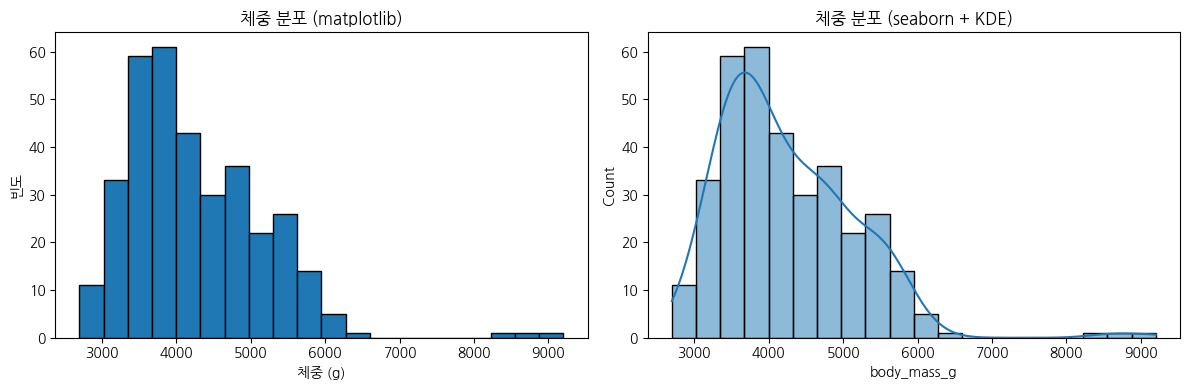

In [19]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# 왼쪽: matplotlib hist
axes[0].hist(df['body_mass_g'], bins=20, edgecolor='black')
axes[0].set_title('체중 분포 (matplotlib)')
axes[0].set_xlabel('체중 (g)')
axes[0].set_ylabel('빈도')
# 오른쪽: seaborn histplot
sns._____(df['body_mass_g'], bins=__, kde=____, ax=axes[1])
axes[1].set_title('체중 분포 (seaborn + KDE)')
plt.tight_layout()
plt.show()

### 5-2 수치형: 박스플롯

Q1, 중앙값, Q3, 이상치를 한 그래프에 담습니다.

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
sns._____(y='body_mass_g', data=df, ax=ax)
ax.set_title('체중 박스플롯')
plt.show()

### 5-3. 범주형: countplot

범주별 빈도를 막대 그래프로 표현합니다.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ['species', 'island', 'sex']):
  sns._____(x=col, data=df, ax=ax)
  ax.set_title(f'{col} 빈도')
plt.tight_layout()
plt.show()
# matplotlib

**[실습 5-1]** bill_length_mm의 분포를 히스토그램(KDE 포함)과 박스플롯으로 나란히 그리세요.

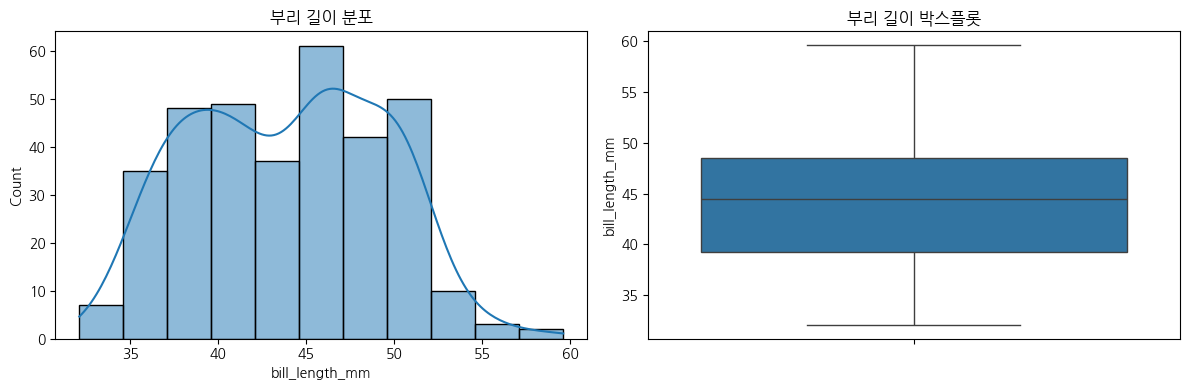

In [20]:
# 여기에 작성하세요. 힌트: subplots(1, 2)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['bill_length_mm'], kde=True, ax=axes[0])
sns.boxplot(y='bill_length_mm', data=df, ax=axes[1])
axes[0].set_title('부리 길이 분포')
axes[1].set_title('부리 길이 박스플롯')
plt.tight_layout()
plt.show()

## 6. 두 컬럼 간 관계 시각화

### 6-1. 수치형 + 수치형: 산점도

상관계수 하나의 숫자로는 두 변수의 관계가 선형인지/비선형인지/이상치가 있는지 알 수 없습니다. 산점도가 답입니다.

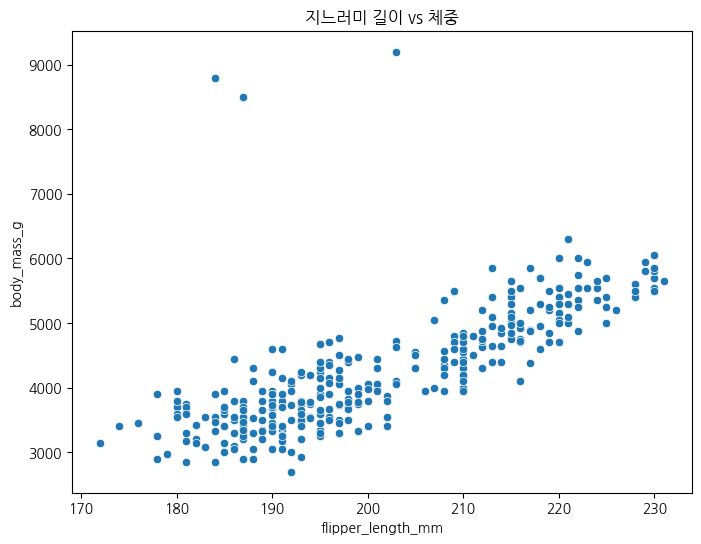

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))
sns._______(x='flipper_length_mm', y='body_mass_g', data=df, ax=ax)
ax.set_title('지느러미 길이 vs 체중')
plt.show()

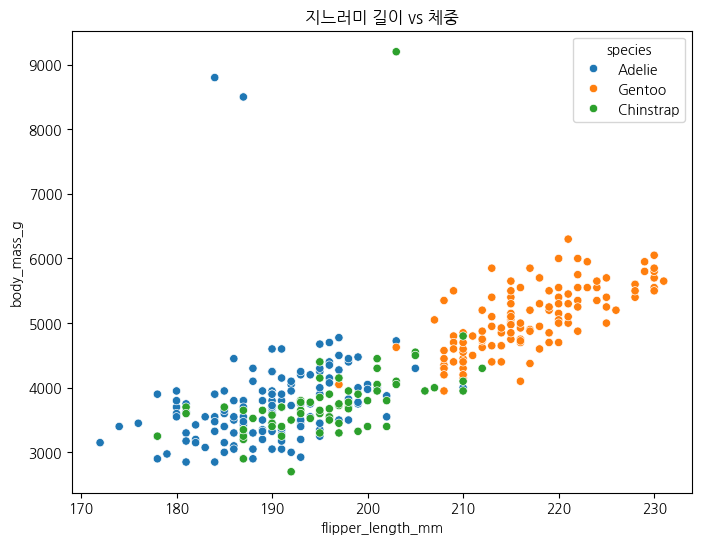

In [22]:
# hue 옵션으로 species별 색을 다르게 하면 그룹 구조가 드러납니다.
fig, ax = plt.subplots(figsize=(8, 6))
sns._______(x='flipper_length_mm', y='body_mass_g', data=df, ax=ax, hue=____)
ax.set_title('지느러미 길이 vs 체중')
plt.show()

### 6-2. 수치형 + 수치형 : regplot (회귀선)

산점도 위에 선형  회귀선을 함께 그려줍니다.

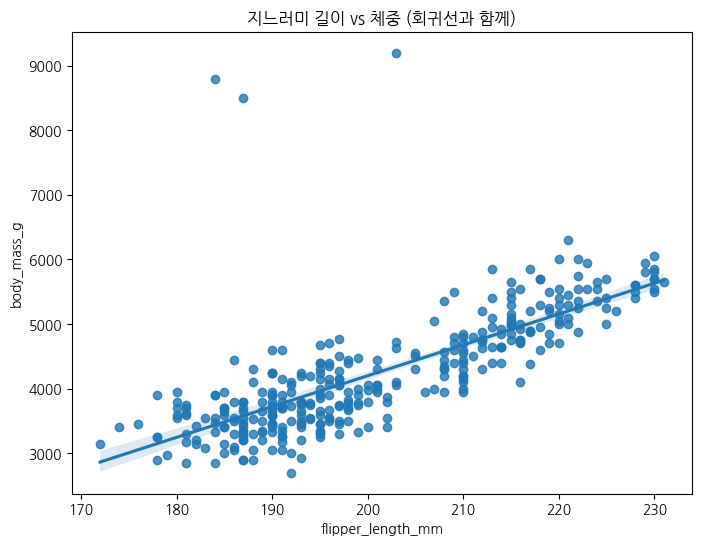

In [24]:
fig, ax = plt.subplots(figsize=(8, 6))
sns._______(x='flipper_length_mm', y='body_mass_g', data=df, ax=ax)
ax.set_title('지느러미 길이 vs 체중 (회귀선과 함께)')
plt.show()

### 6-3. 수치형 + 범주형: 박스플롯, 바이올린플롯

그룹 간 분포를 비교합니다. 박스플롯은 사분위수 정보, 바이올린 플롯은 분포 형태까지 보여줍니다.

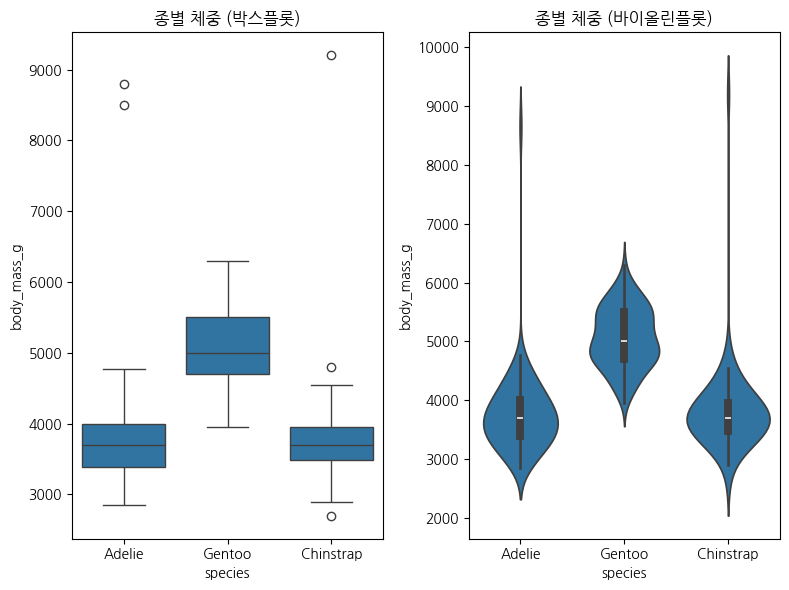

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(8, 6))
sns.____(x='species', y='body_mass_g', data=df, ax=axes[0])
axes[0].set_title('종별 체중 (박스플롯)')
sns.____(x='species', y='body_mass_g', data=df, ax=axes[1])
axes[1].set_title('종별 체중 (바이올린플롯)')
plt.tight_layout()
plt.show()

### 6-4. 범주형 + 범주형: 교차표 + 히트맵

두 범주형 변수의 빈도를 색상으로 표현합니다.

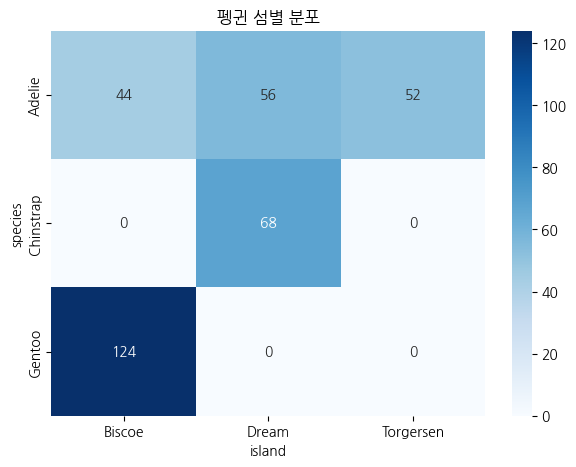

In [28]:
ct = pd.crosstab(df['species'], df['island'])
fig, ax = plt.subplots(figsize=(7, 5))
sns._____(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('펭귄 섬별 분포')
plt.show()

**[실습 6-1]** bill_length_mm(x)과 bill_depth_mm(y)의 산점도를 종(species)별로 색을 달리해 그리세요. 종마다 분포가 어떻게 다른 지 관찰해보세요.

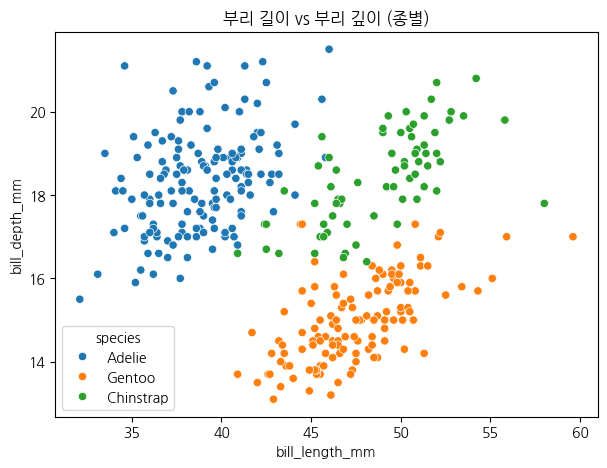

In [30]:
# 여기에 작성해보세요.
fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(x='bill_length_mm', y='bill_depth_mm', hue='species', data=df, ax=ax)
ax.set_title('부리 길이 vs 부리 깊이 (종별)')
plt.show()

## 7. 다중 변수 / 고급 시각화

### 7-1. 상관관계 히트맵

수치형 컬럼 전체의 상관계수를 한 눈에 봅니다.

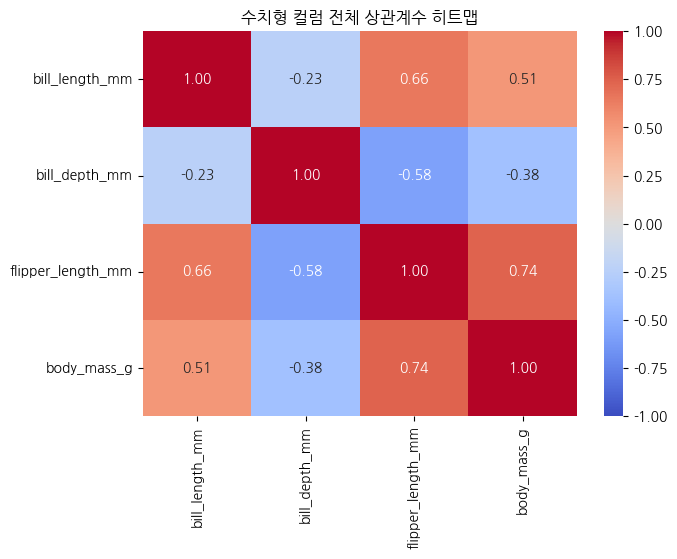

In [33]:
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', ax=ax, vmin=-1, vmax=1)
ax.set_title('수치형 컬럼 전체 상관계수 히트맵')
plt.show()

### 7-2. pairplot - 모든 수치형 변수 쌍

모든 수치형 컬럼 쌍의 산점도와 각 컬럼의 분포를 한 번에 그립니다. **EDA 초기에 매우 유용**합니다.

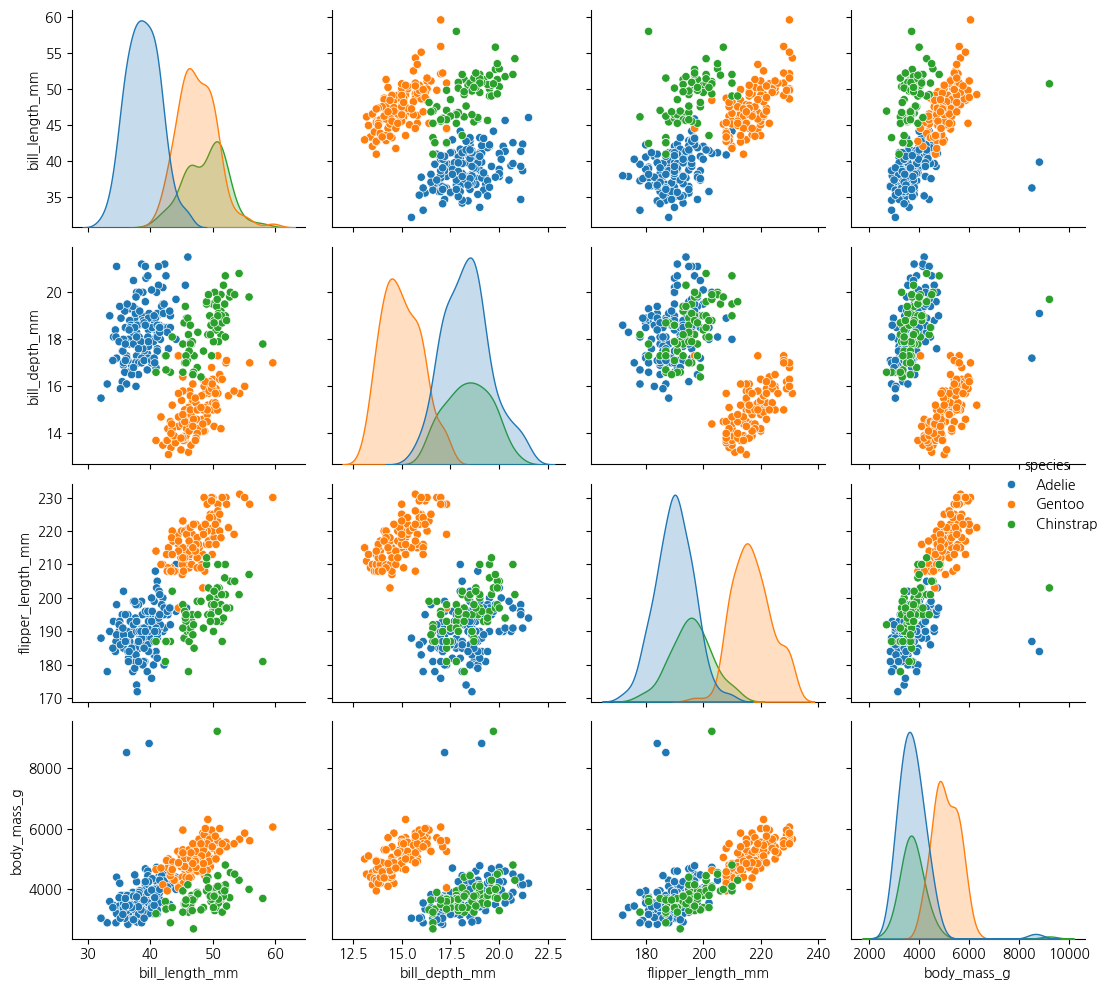

In [34]:
# Pairplot은 figure 단위로 그려지므로 ax를 따로 만들지 않습니다.
sns._____(df, vars=num_cols, hue='species', diag_kind='kde')
plt.tight_layout()
plt.show()

### 7-3. jointplot - 두 변수의 관계 + 각 변수의 분포

산점도 + 각 축의 분포(히스토그램)를 한 그림에 담습니다.
`KDE` 옵션으로 표현 방식을 바꿀 수 있습니다.

- `kind='scatter'` : 산점도 (기본)
- `kind='kde'` : 커널 밀도 등고선
- `kind='hex'` : 육각형 빈도 (밀도 표현, 점이 많을 때 유용)
- `kind='reg'` : 산점도 + 회귀선

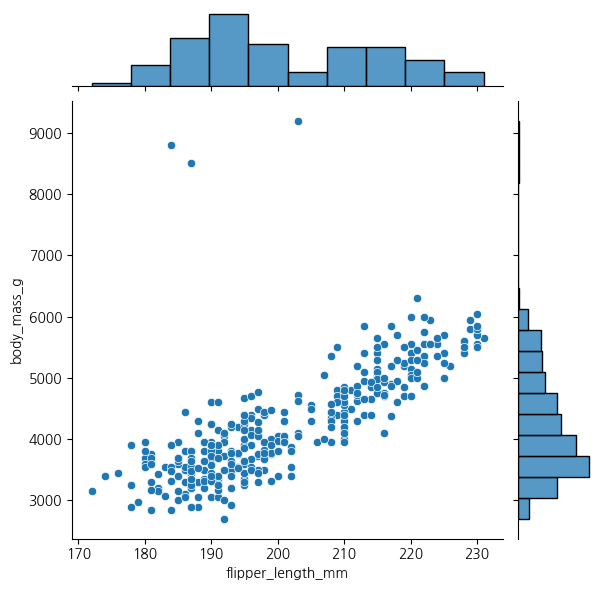

In [35]:
# scatter 방식
sns.jointplot(x='flipper_length_mm', y='body_mass_g', data=df, kind=_____)
plt.show()
#

In [ ]:
# kde 방식 (등고선으로 밀도 표현)
sns.jointplot(x='flipper_length_mm', y='body_mass_g', data=df, kind=_____)
plt.show()

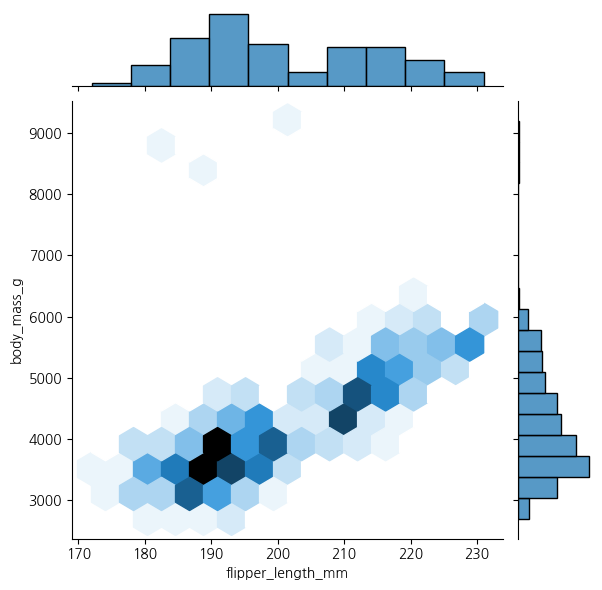

In [36]:
# hex 방식 (육각형 빈도 표현)
sns.jointplot(x='flipper_length_mm', y='body_mass_g', data=df, kind=_____)
plt.show()

### 7-4. KDE 등고선 (kdeplot)

산점도 위에 밀도 등고선을 겹쳐 그릴 수 있습니다.

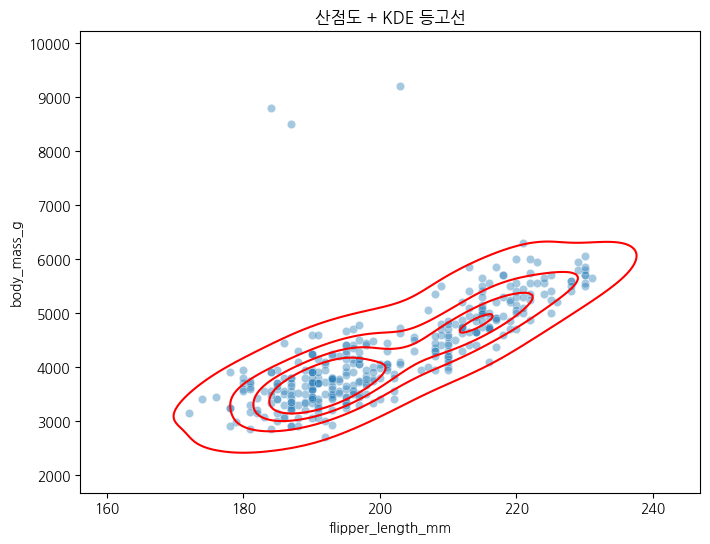

In [38]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(x='flipper_length_mm', y='body_mass_g', data=df, alpha=.4, ax=ax)
sns._____(x='flipper_length_mm', y='body_mass_g', data=df, levels=5, color='red', ax=ax)
ax.set_title('산점도 + KDE 등고선')
plt.show()

**[실습 7-1]** species별 색을 적용한 KDE 등고선을 그려보세요. (힌트: kdeplot에 hue='species' 옵션 사용)

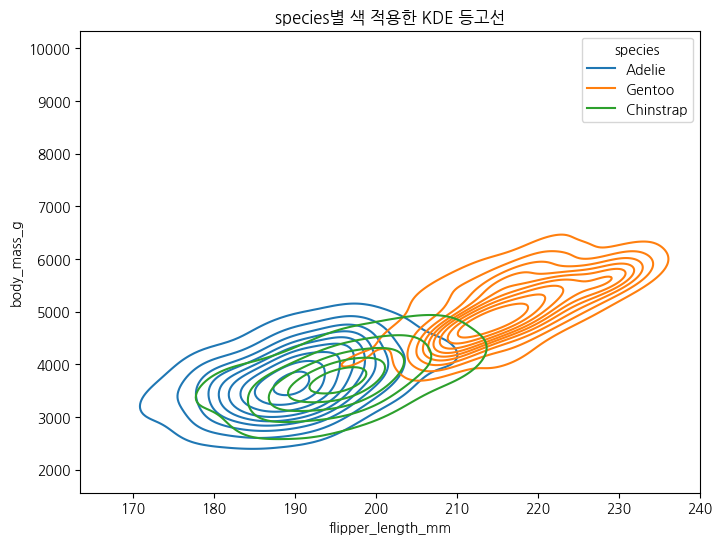

In [44]:
# 여기에 작성하세요.
fig, ax = plt.subplots(figsize=(8, 6))
sns.kdeplot(x='flipper_length_mm', y='body_mass_g', hue='species', data=df,  ax=ax)
ax.set_title('species별 색 적용한 KDE 등고선')
plt.show()

In [39]:
# 1. species별 수치형 컬럼 평균

In [40]:
# 2. species x sex 평균 body_mass_g 피벗 (unstack() : 피벗테이블)

In [41]:
# 3. 수치형 컬럼 상관관계 히트맵

In [42]:
# 4. species별 body_mass_g 바이올린플롯

In [ ]:
# 5. bill_length_mm vs flipper_length_mm jointplot

# numpy를 이용한 신경망 기본 이론 습득

**데이터 셋**: numpy로 random 생성

**학습 목표**
- numpy로 임의의 값으로 채워진 변수를 생성할 수 있다.
- neural network 신경망 학습의 기본 내용을 이해할 수 있다.
- activation (활성화함수)를 시각화할 수 있다.
- backpropargation(역전파) 계산 및 모델 예측 결과를 표현할 수 있다.

## 선형 회귀의 경사(Gradient of a line)

선형회귀 모델에 대한 수식이 아래와 같습니다.
$$y = wx + \epsilon$$

이에 대한 손실함수는 평균제곱오차(mse)를 많이 사용합니다.
$$\text{MSE} = \frac{1}{n} \sum_i (y - \hat{y}_i)^2$$

n개의 샘플을 가지고 아래와 같이 계산할 수 있습니다.

\
\begin{aligned}
\frac{\partial}{\partial w_1} \frac{1}{n} \sum_i (y - w_1 x)^2
&= \frac{2}{n} \sum_i (y - w_1 x)(-x) \\
&= -\frac{2}{n} \sum_i (y - w_1 x)x
\end{aligned}


In [45]:
import numpy as np
np.random.seed(42) # 재현성을 위한 seed 고정
# 임의의 x에 대한 출력 y를 생성하세요.
X = np.random.rand(100, 1)
y = np._____(X > .5, 1, 0) # 목표 y는 X의 반올림 수
X, y

(array([[0.37454012],
        [0.95071431],
        [0.73199394],
        [0.59865848],
        [0.15601864],
        [0.15599452],
        [0.05808361],
        [0.86617615],
        [0.60111501],
        [0.70807258],
        [0.02058449],
        [0.96990985],
        [0.83244264],
        [0.21233911],
        [0.18182497],
        [0.18340451],
        [0.30424224],
        [0.52475643],
        [0.43194502],
        [0.29122914],
        [0.61185289],
        [0.13949386],
        [0.29214465],
        [0.36636184],
        [0.45606998],
        [0.78517596],
        [0.19967378],
        [0.51423444],
        [0.59241457],
        [0.04645041],
        [0.60754485],
        [0.17052412],
        [0.06505159],
        [0.94888554],
        [0.96563203],
        [0.80839735],
        [0.30461377],
        [0.09767211],
        [0.68423303],
        [0.44015249],
        [0.12203823],
        [0.49517691],
        [0.03438852],
        [0.9093204 ],
        [0.25877998],
        [0

In [46]:
# sigmoid 함수를 작성하세요.
def sigmoid(z):
  # sigmoid 공식 계산값을 반환하세요.
  return 1 / (1 + np.____(-z))

In [ ]:
# MSE 손실함수를 작성하세요.
def loss_function(y, yhat):
  # 평균 제곱 오차를 계산하세요.
  return np.____(y - yhat)

In [ ]:
# 가중치와 절편에 대한 미분을 계산하는 함수를 작성하세요.
def compute_gradient(X, y, yhat):
  # 가중치 w(weight)에 대한 미분은 dw , 절편 b(bias)에 대한 미분은 db 로 표현하세요.
  dw = np.___(X.T, (y - yhat)) / y.size
  db = np.___(y - yhat) / y.size
  return dw, db

In [ ]:
# 훈련(training)하는 함수를 작성하세요.
def train(X, y, iterations, lr):
  # 손실값을 저장할 빈 리스트를 만들고 가중치와 절편을 0으로 초기화합니다.
  losses = []
  w = np._____((X.shape[1], 1))
  b = 0
  for i in range(iterations):
    # 순방향(Feed Forward network) 계산하는 함수를 만드세요.
    z = np.___(X, w) + b
    yhat = sigmoid(z)
    # 손실 값을 계산하는 함수를 호출하세요.
    loss = ____________(y, yhat)
    # 손실 값을 리스트에 추가합니다.
    losses.append(loss)
    # 역방향(Backward pass Backpropagation) 기울기(gradients)를 계산하세요.
    dw, db = _____________________(X, y, yhat)
    # 파라미터(w, b)를 업데이트하세요.
    w -= lr * dw
    b -= lr * db
  return w, b, losses